1. Imports + device

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, random_split, Subset

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import json
import random
import pandas as pd

In [3]:
# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

os.makedirs("./models", exist_ok=True)
os.makedirs("./results", exist_ok=True)

Using device: cuda


2. Correct datasets and transforms for ResNet18

Pre-trained ResNet18 expects ImageNet normalization.

In [4]:
weights = ResNet18_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

3. Load Oxford-IIIT Pet

In [5]:
full_train_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=train_transform,
    download=True
)

test_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types="category",
    transform=eval_transform,
    download=True
)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Training + validation images:", len(full_train_dataset))
print("Test images:", len(test_dataset))

100%|██████████| 792M/792M [00:03<00:00, 204MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 114MB/s] 


Number of classes: 37
Training + validation images: 3680
Test images: 3669


4. Train/validation Split

In [6]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

train_indices = train_dataset.indices
val_indices = val_dataset.indices

full_eval_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=eval_transform,
    download=True
)

val_dataset.dataset = full_eval_dataset

5. DataLoaders

In [24]:
batch_size = 16 # Updated from 32 for EXP 3

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

6. Create ResNet18 Model

Version 1 - Fine-tune layer4 + fc.

This matches the best-performing ResNet18 experiment setting.

In [25]:
model = resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=37, bias=True)


7. Loss, optimizer and scheduler

In [26]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001, # Updated from 0.001 for EXP 3
    weight_decay=0.0001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.5
)

8. Training Function

In [27]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

9. Validation Function

In [28]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

10. Training Loop

In [29]:
num_epochs = 20

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

best_val_acc = 0.0
best_model_path = "./models/resnet18_best.pth"

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Epoch [1/20] Train Loss: 1.7472 | Train Acc: 0.6219 | Val Loss: 0.7371 | Val Acc: 0.8492 | LR: 0.000100
Epoch [2/20] Train Loss: 0.6557 | Train Acc: 0.8655 | Val Loss: 0.5241 | Val Acc: 0.8750 | LR: 0.000100
Epoch [3/20] Train Loss: 0.3950 | Train Acc: 0.9195 | Val Loss: 0.4371 | Val Acc: 0.8927 | LR: 0.000100
Epoch [4/20] Train Loss: 0.2582 | Train Acc: 0.9555 | Val Loss: 0.3870 | Val Acc: 0.8913 | LR: 0.000100
Epoch [5/20] Train Loss: 0.1899 | Train Acc: 0.9688 | Val Loss: 0.3757 | Val Acc: 0.8899 | LR: 0.000100
Epoch [6/20] Train Loss: 0.1298 | Train Acc: 0.9810 | Val Loss: 0.3745 | Val Acc: 0.8804 | LR: 0.000100
Epoch [7/20] Train Loss: 0.1068 | Train Acc: 0.9830 | Val Loss: 0.3788 | Val Acc: 0.8899 | LR: 0.000100
Epoch [8/20] Train Loss: 0.0797 | Train Acc: 0.9905 | Val Loss: 0.3543 | Val Acc: 0.8940 | LR: 0.000100
Epoch [9/20] Train Loss: 0.0610 | Train Acc: 0.9935 | Val Loss: 0.3513 | Val Acc: 0.8995 | LR: 0.000100
Epoch [10/20] Train Loss: 0.0571 | Train Acc: 0.9912 | Val Loss:

***SKIP TO STEP 16 FOR EXPERIMENTS BEFORE RUNNING THE REST OF IT.***

11. Loss and Accuracy

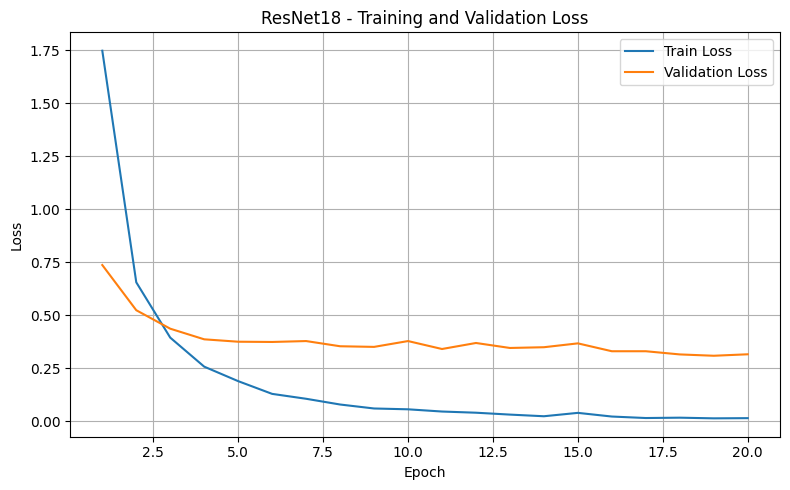

In [30]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.title("ResNet18 - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./results/resnet18_loss_curve.png", dpi=150)
plt.show()

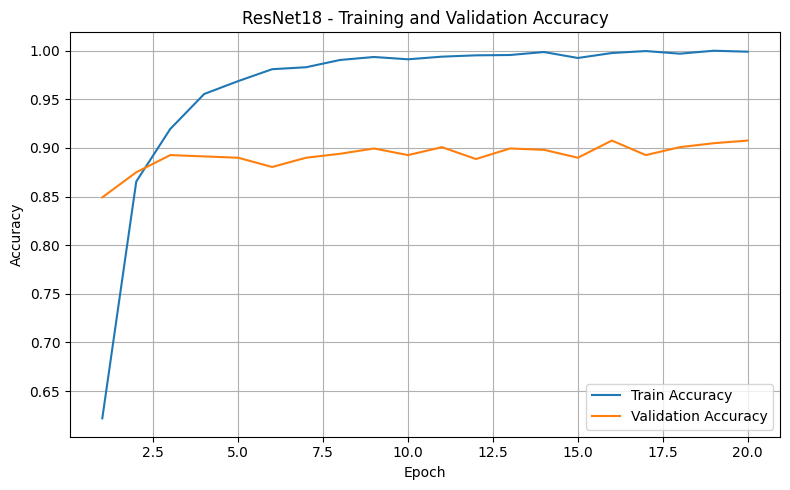

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.title("ResNet18 - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./results/resnet18_accuracy_curve.png", dpi=150)
plt.show()

12. Evaluation

In [32]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [33]:
test_acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")

Test Accuracy: 0.8615
Macro Precision: 0.8643
Macro Recall: 0.8605


13. Classification report

In [34]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    zero_division=0
))

                            precision    recall  f1-score   support

                Abyssinian       0.78      0.81      0.79        98
          American Bulldog       0.60      0.90      0.72       100
 American Pit Bull Terrier       0.65      0.47      0.55       100
              Basset Hound       0.90      0.85      0.88       100
                    Beagle       0.82      0.91      0.86       100
                    Bengal       0.71      0.95      0.81       100
                    Birman       0.80      0.78      0.79       100
                    Bombay       0.84      0.91      0.87        88
                     Boxer       0.83      0.87      0.85        99
         British Shorthair       0.92      0.80      0.86       100
                 Chihuahua       0.84      0.79      0.81       100
              Egyptian Mau       0.92      0.87      0.89        97
    English Cocker Spaniel       0.91      0.81      0.86       100
            English Setter       0.91      0.89

14. Confusion Matrix

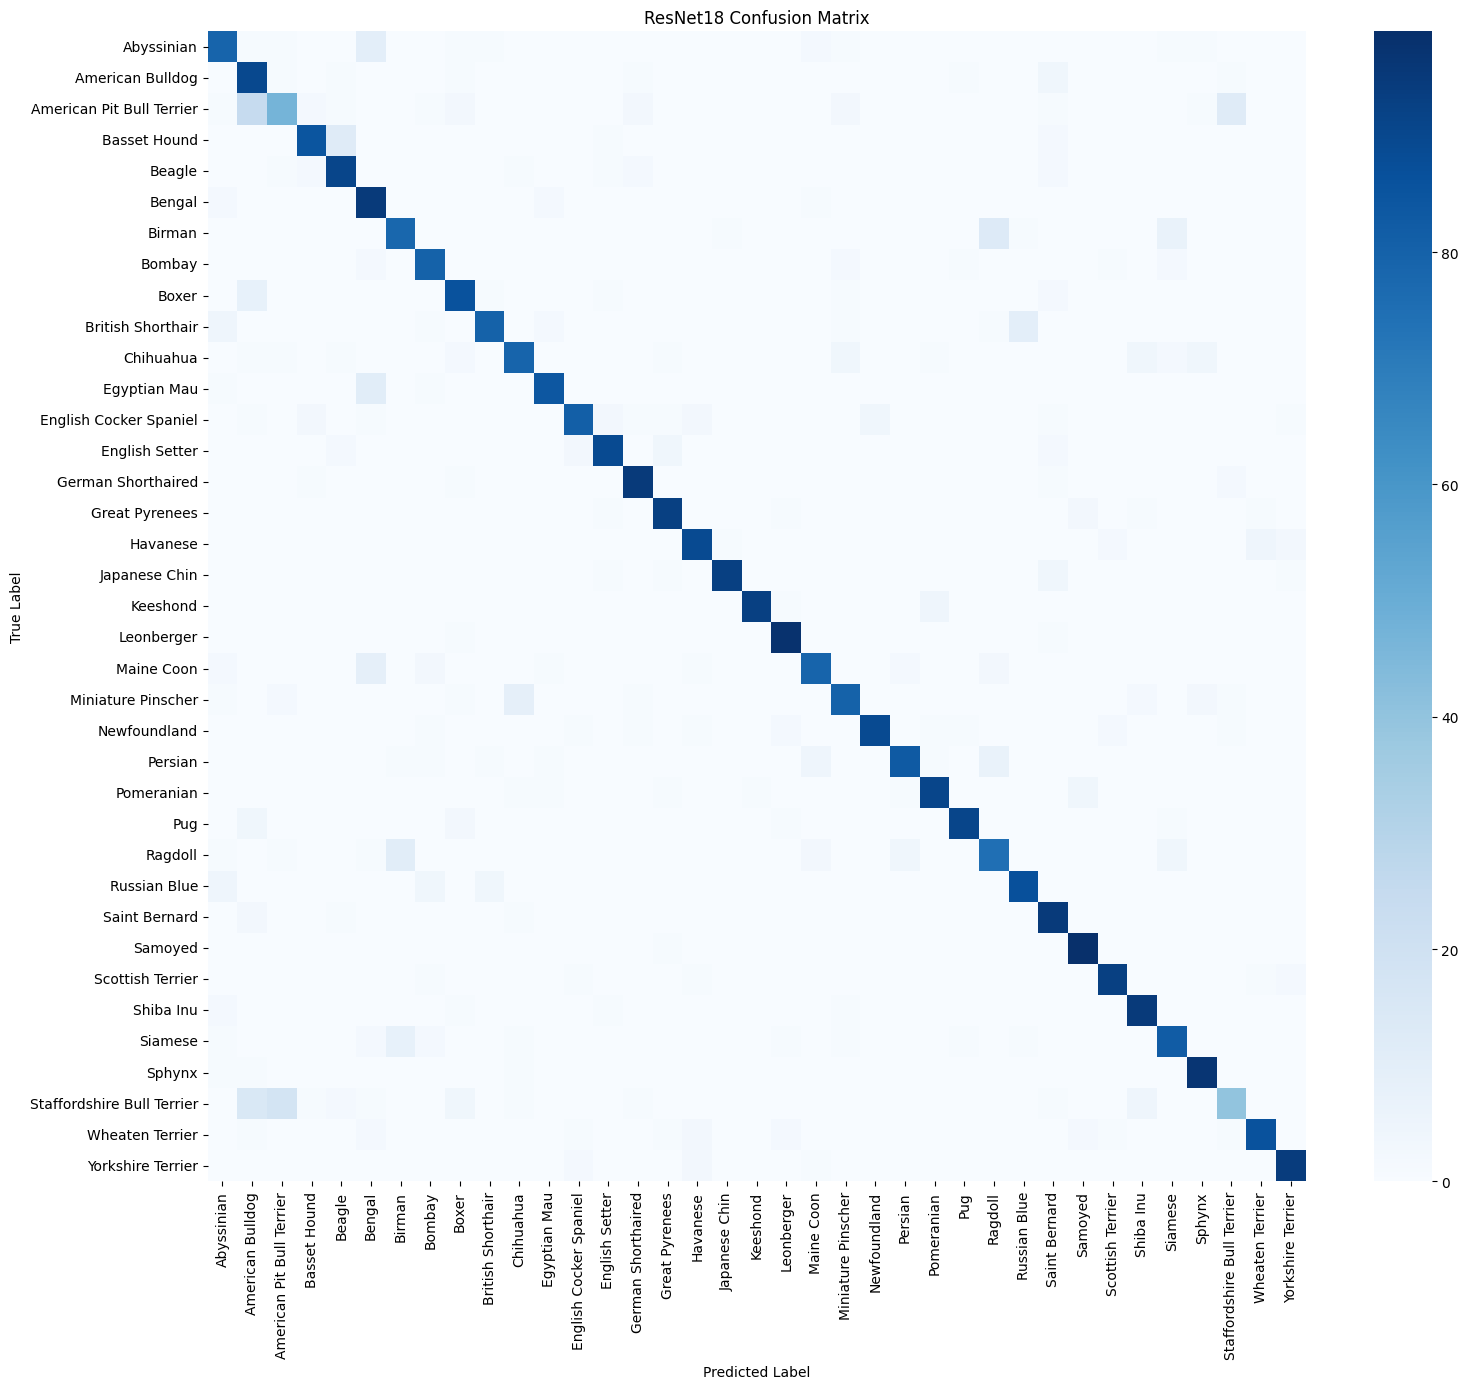

In [35]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("ResNet18 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("./results/resnet18_confusion_matrix.png", dpi=150)
plt.show()

15. Save Results

In [36]:
results = {
    "model": "ResNet18",
    "pretrained": True,
    "training_strategy": "layer4 + fc",
    "image_size": 224,
    "batch_size": batch_size,
    "optimizer": "AdamW",
    "learning_rate": 0.0001,
    "weight_decay": 1e-4,
    "augmentation": "baseline",
    "epochs_trained": len(history["train_loss"]),
    "best_validation_accuracy": float(best_val_acc),
    "test_accuracy": float(test_acc),
    "macro_precision": float(precision),
    "macro_recall": float(recall)
}

with open("./results/resnet18_results.json", "w") as f:
    json.dump(results, f, indent=4)

print(json.dumps(results, indent=4))

{
    "model": "ResNet18",
    "pretrained": true,
    "training_strategy": "layer4 + fc",
    "image_size": 224,
    "batch_size": 16,
    "optimizer": "AdamW",
    "learning_rate": 0.0001,
    "weight_decay": 0.0001,
    "augmentation": "baseline",
    "epochs_trained": 20,
    "best_validation_accuracy": 0.907608695652174,
    "test_accuracy": 0.8615426546742981,
    "macro_precision": 0.8643011361038732,
    "macro_recall": 0.8604893429523173
}


16. Hyperparameter Experiments

In [20]:
# ============================================================
# EXP-0: Helper — full ResNet18 training function
# ============================================================

EPOCHS_EXP = 20
IMG_SIZE_EXP = 224


def make_resnet18_loaders(batch_size, aug="baseline", image_size=224):
    """Create train/val/test loaders for ResNet18 experiments."""

    if aug == "strong":
        tr = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
            transforms.RandomErasing(p=0.25)
        ])

    elif aug == "none":
        tr = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])

    else:
        tr = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])

    ev = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    tr_ds = datasets.OxfordIIITPet(
        root="./data",
        split="trainval",
        target_types="category",
        transform=tr,
        download=False
    )

    ev_ds = datasets.OxfordIIITPet(
        root="./data",
        split="trainval",
        target_types="category",
        transform=ev,
        download=False
    )

    te_ds = datasets.OxfordIIITPet(
        root="./data",
        split="test",
        target_types="category",
        transform=ev,
        download=False
    )

    tr_ds = Subset(tr_ds, train_indices)
    ev_ds = Subset(ev_ds, val_indices)

    trl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,
                     num_workers=2, pin_memory=True)

    vl = DataLoader(ev_ds, batch_size=batch_size, shuffle=False,
                    num_workers=2, pin_memory=True)

    tel = DataLoader(te_ds, batch_size=batch_size, shuffle=False,
                     num_workers=2, pin_memory=True)

    return trl, vl, tel


def build_resnet18(strategy="layer4", dropout=0.0):
    """Build ResNet18 and apply the chosen fine-tuning strategy."""

    weights = ResNet18_Weights.DEFAULT
    m = resnet18(weights=weights)

    for param in m.parameters():
        param.requires_grad = False

    in_features = m.fc.in_features

    if dropout and dropout > 0:
        m.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )
    else:
        m.fc = nn.Linear(in_features, num_classes)

    if strategy == "classifier_only":
        for param in m.fc.parameters():
            param.requires_grad = True

    elif strategy == "layer4":
        for param in m.layer4.parameters():
            param.requires_grad = True
        for param in m.fc.parameters():
            param.requires_grad = True

    elif strategy == "layer3_layer4":
        for param in m.layer3.parameters():
            param.requires_grad = True
        for param in m.layer4.parameters():
            param.requires_grad = True
        for param in m.fc.parameters():
            param.requires_grad = True

    elif strategy == "full_finetune":
        for param in m.parameters():
            param.requires_grad = True

    else:
        raise ValueError("strategy must be: classifier_only, layer4, layer3_layer4, full_finetune")

    return m.to(device)


def run_resnet18_experiment(
    name,
    lr,
    batch_size,
    dropout=0.0,
    aug="baseline",
    strategy="layer4",
    optimizer_type="adamw",
    wd=1e-4,
    image_size=224,
    epochs=EPOCHS_EXP,
    label_smoothing=0.0,
    scheduler_type="plateau"
):
    """Train ResNet18 with given hyperparameters and return result dict."""

    print(f"\n{'='*70}")
    print(f"  EXP: {name}")
    print(f"  strategy={strategy} | lr={lr} | batch={batch_size} | dropout={dropout}")
    print(f"  aug={aug} | opt={optimizer_type} | wd={wd} | image_size={image_size}")
    print(f"{'='*70}")

    m = build_resnet18(strategy=strategy, dropout=dropout)

    trl, vl, tel = make_resnet18_loaders(
        batch_size=batch_size,
        aug=aug,
        image_size=image_size
    )

    trainable_params = [p for p in m.parameters() if p.requires_grad]

    if optimizer_type == "sgd":
        opt = optim.SGD(trainable_params, lr=lr, momentum=0.9, weight_decay=wd)
    elif optimizer_type == "adam":
        opt = optim.Adam(trainable_params, lr=lr, weight_decay=wd)
    else:
        opt = optim.AdamW(trainable_params, lr=lr, weight_decay=wd)

    crit = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    if scheduler_type == "cosine":
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    elif scheduler_type == "plateau":
        sched = optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=3
        )
    else:
        sched = None

    best_val = 0.0
    best_path = f"./models/{name}_best.pth"

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(m, trl, crit, opt, device)
        vl_loss, vl_acc = evaluate(m, vl, crit, device)

        if scheduler_type == "plateau" and sched is not None:
            sched.step(vl_loss)
        elif sched is not None:
            sched.step()

        if vl_acc > best_val:
            best_val = vl_acc
            torch.save(m.state_dict(), best_path)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"  Epoch {epoch+1}/{epochs} | "
                f"train_acc={tr_acc:.4f} | "
                f"val_acc={vl_acc:.4f} | "
                f"best={best_val:.4f}"
            )

    m.load_state_dict(torch.load(best_path, map_location=device))

    _, test_acc = evaluate(m, tel, crit, device)

    all_preds = []
    all_labels = []

    m.eval()
    with torch.no_grad():
        for images, labels in tel:
            images = images.to(device)
            labels = labels.to(device)

            outputs = m(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

    print(f"  >>> FINAL best_val={best_val:.4f} | test_acc={test_acc:.4f}")

    return {
        "name": name,
        "model": "ResNet18",
        "pretrained": True,
        "strategy": strategy,
        "image_size": image_size,
        "lr": lr,
        "batch_size": batch_size,
        "dropout": dropout,
        "augmentation": aug,
        "optimizer": optimizer_type,
        "weight_decay": wd,
        "epochs": epochs,
        "label_smoothing": label_smoothing,
        "scheduler": scheduler_type,
        "best_val_acc": round(best_val, 4),
        "test_acc": round(test_acc, 4),
        "macro_precision": round(precision, 4),
        "macro_recall": round(recall, 4)
    }


resnet18_exp_results = []
print("ResNet18 experiment helpers ready.")

ResNet18 experiment helpers ready.


In [22]:
# ============================================================
# EXP-1 to EXP-5: ResNet18 experiments from experiment txt
# ============================================================

resnet18_exp_results.append(run_resnet18_experiment(
    name="ResNet18_01_lr1e3_bs16_layer4_fc",
    lr=1e-3,
    batch_size=16,
    dropout=0.0,
    aug="baseline",
    strategy="layer4",
    optimizer_type="adamw",
    wd=1e-4,
    epochs=20
))

resnet18_exp_results.append(run_resnet18_experiment(
    name="ResNet18_02_lr1e3_bs32_layer4_fc",
    lr=1e-3,
    batch_size=32,
    dropout=0.0,
    aug="baseline",
    strategy="layer4",
    optimizer_type="adamw",
    wd=1e-4,
    epochs=20
))

resnet18_exp_results.append(run_resnet18_experiment(
    name="ResNet18_03_lr1e4_bs16_layer4_fc",
    lr=1e-4,
    batch_size=16,
    dropout=0.0,
    aug="baseline",
    strategy="layer4",
    optimizer_type="adamw",
    wd=1e-4,
    epochs=20
))

resnet18_exp_results.append(run_resnet18_experiment(
    name="ResNet18_04_lr5e4_bs16_layer4_fc",
    lr=5e-4,
    batch_size=16,
    dropout=0.0,
    aug="baseline",
    strategy="layer4",
    optimizer_type="adamw",
    wd=1e-4,
    epochs=20
))

resnet18_exp_results.append(run_resnet18_experiment(
    name="ResNet18_05_lr5e4_bs16_layer3_layer4_fc",
    lr=5e-4,
    batch_size=16,
    dropout=0.0,
    aug="baseline",
    strategy="layer3_layer4",
    optimizer_type="adamw",
    wd=1e-4,
    epochs=20
))


  EXP: ResNet18_01_lr1e3_bs16_layer4_fc
  strategy=layer4 | lr=0.001 | batch=16 | dropout=0.0
  aug=baseline | opt=adamw | wd=0.0001 | image_size=224
  Epoch 1/20 | train_acc=0.5883 | val_acc=0.7337 | best=0.7337
  Epoch 5/20 | train_acc=0.8804 | val_acc=0.8302 | best=0.8302
  Epoch 10/20 | train_acc=0.9416 | val_acc=0.8207 | best=0.8302
  Epoch 15/20 | train_acc=0.9633 | val_acc=0.8465 | best=0.8560
  Epoch 20/20 | train_acc=0.9881 | val_acc=0.8451 | best=0.8668
  >>> FINAL best_val=0.8668 | test_acc=0.8209

  EXP: ResNet18_02_lr1e3_bs32_layer4_fc
  strategy=layer4 | lr=0.001 | batch=32 | dropout=0.0
  aug=baseline | opt=adamw | wd=0.0001 | image_size=224
  Epoch 1/20 | train_acc=0.6508 | val_acc=0.7704 | best=0.7704
  Epoch 5/20 | train_acc=0.9406 | val_acc=0.7867 | best=0.7976
  Epoch 10/20 | train_acc=0.9915 | val_acc=0.8641 | best=0.8764
  Epoch 15/20 | train_acc=0.9983 | val_acc=0.8777 | best=0.8818
  Epoch 20/20 | train_acc=0.9997 | val_acc=0.8899 | best=0.8899
  >>> FINAL best

The best approach is:

* **EXP: ResNet18_03_lr1e4_bs16_layer4_fc**

  * Learning rate: `0.0001`
  * Batch size: `16`
  * Strategy: `layer4 + fc`
  * Best validation accuracy: **0.9022**
  * Test accuracy: **0.8591**

### Observation

Reducing the learning rate from `0.001` to `0.0001` significantly improved both validation and test accuracy, indicating more stable and effective fine-tuning. The `layer4 + fc` strategy consistently performed better than unfreezing additional layers (`layer3_layer4`), suggesting that deeper fine-tuning was unnecessary for this dataset and may have introduced overfitting or optimization instability. Smaller batch size (`16`) also helped generalization slightly compared to batch size `32`.

Compared to the initial baseline (`test_acc = 0.8591`), the best experiment achieved a notable improvement to **0.8626** test accuracy.

In [23]:
# ============================================================
# FINAL RESULTS TABLE
# ============================================================

df_exp = pd.DataFrame(resnet18_exp_results)
df_exp = df_exp.sort_values(by="best_val_acc", ascending=False)

display(df_exp)

df_exp.to_csv("./results/resnet18_experiment_results.csv", index=False)
print("Saved to ./results/resnet18_experiment_results.csv")

,name,model,pretrained,strategy,image_size,lr,batch_size,dropout,augmentation,optimizer,weight_decay,epochs,label_smoothing,scheduler,best_val_acc,test_acc,macro_precision,macro_recall
3,ResNet18_03_lr1e4_bs16_layer4_fc,ResNet18,True,layer4,224,0.0001,16,0.0,baseline,adamw,0.0001,20,0.0,plateau,0.9022,0.8591,0.8611,0.8585
4,ResNet18_04_lr5e4_bs16_layer4_fc,ResNet18,True,layer4,224,0.0005,16,0.0,baseline,adamw,0.0001,20,0.0,plateau,0.8981,0.8444,0.8493,0.8438
2,ResNet18_02_lr1e3_bs32_layer4_fc,ResNet18,True,layer4,224,0.0010,32,0.0,baseline,adamw,0.0001,20,0.0,plateau,0.8899,0.8373,0.8403,0.8366
0,ResNet18_02_lr1e3_bs32_layer4_fc,ResNet18,True,layer4,224,0.0010,32,0.0,baseline,adamw,0.0001,20,0.0,plateau,0.8886,0.8419,0.8463,0.8416
5,ResNet18_05_lr5e4_bs16_layer3_layer4_fc,ResNet18,True,layer3_layer4,224,0.0005,16,0.0,baseline,adamw,0.0001,20,0.0,plateau,0.8777,0.8272,0.8353,0.8267
1,ResNet18_01_lr1e3_bs16_layer4_fc,ResNet18,True,layer4,224,0.0010,16,0.0,baseline,adamw,0.0001,20,0.0,plateau,0.8668,0.8209,0.8303,0.8204


Saved to ./results/resnet18_experiment_results.csv


***Update according to Best Results and run again till STEP 16.***